In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data3,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix1
CUDA_LAUNCH_BLOCKING=3

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): #x为数据，a，b均为中心点
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)

    

cuda:3


In [2]:
import copy
Nx,Ny,Nz=1,1,1
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=0,1,0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.5,1.5,-0.5,1.5,-0.5,1.5 #边界gamma处
num_batches_gauss=1
b_n=10
points_b=mea_3D.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_1=np.array([0.3,0.5,0.3])
center_2=np.array([0.5,0.5,0.8])
center_true=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1
cupy_device = 3

In [3]:
F_81_5_15=np.load("./noise=5%/F_81_5%.npy")

In [6]:
M=7200
af="Tanh"   #先用tanh
R_m=10
models0 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=[], r_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,device=device).to(device)

In [5]:
models0=torch.load("./noise=5%/model_tanh.pth", map_location=device)

Plotting 64 cells. Levels: 0 to 0


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.7/./main_code/main_fix1.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


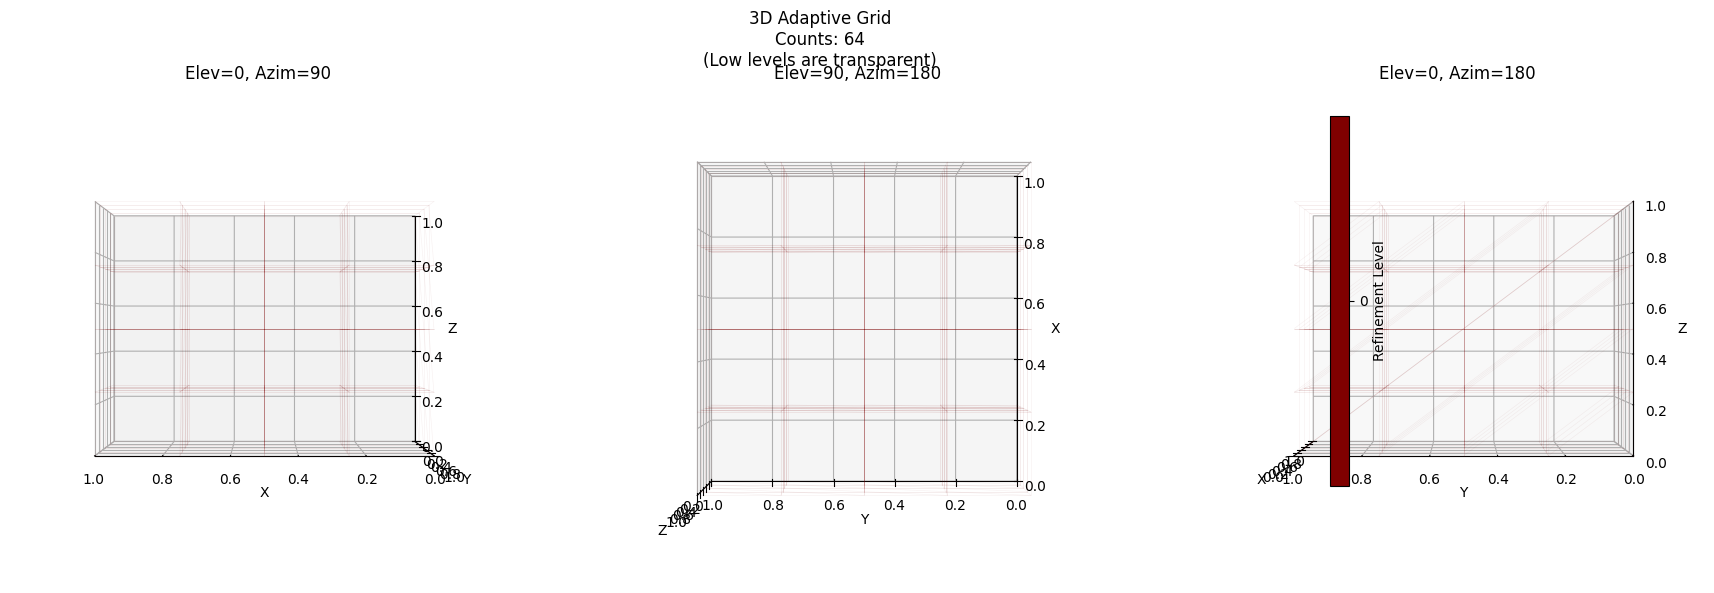

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


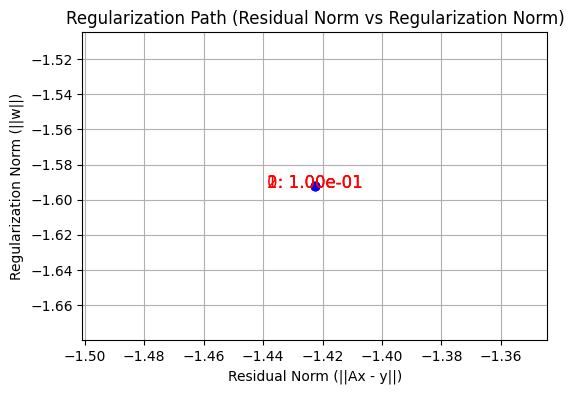

第 0 次迭代的train误差：
S_l_inf= 5.296235494832408 S_L_2= 0.012696760672994549 S_l_2= 0.710982703081013
第 0 次迭代的泛化误差：


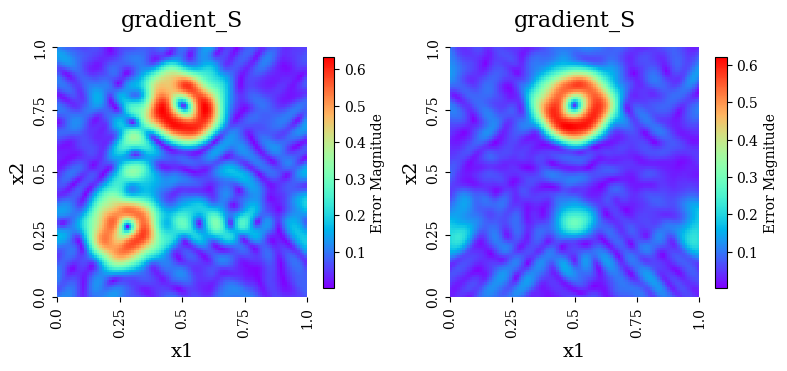

S_l_inf= 8.498750418136977 S_L_2= 0.011921277916562069 S_l_2= 0.739041008264577


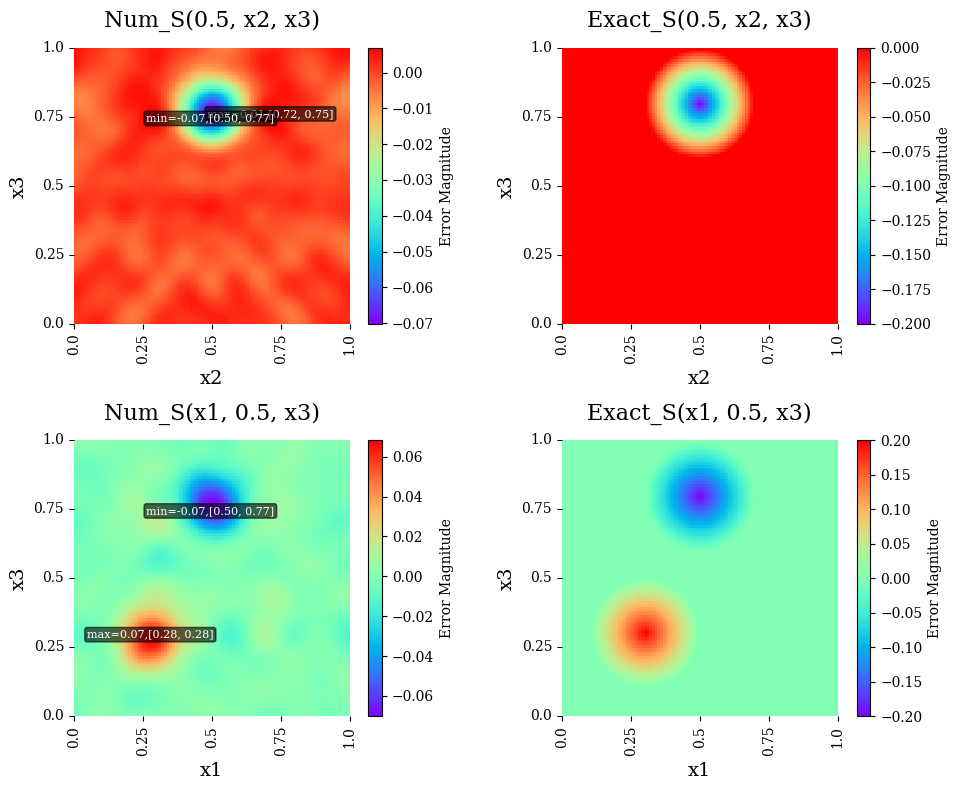

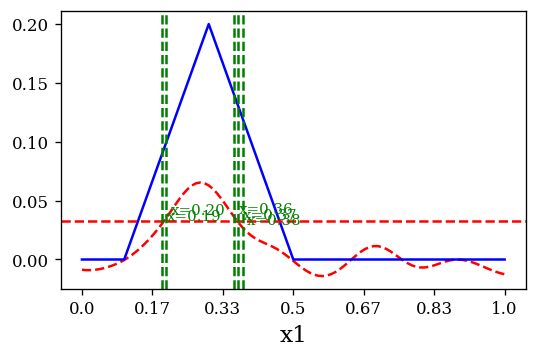

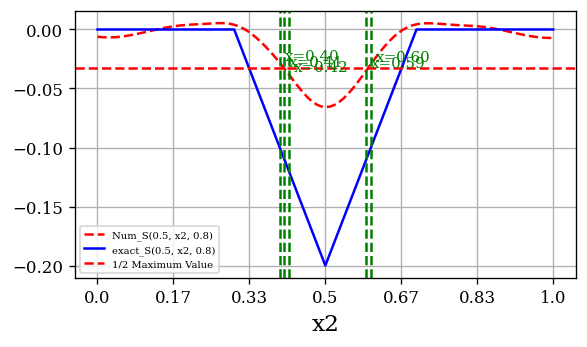

第 0 次自适应网格细分...
S_l_inf= 5.296235494832408 S_L_2= 0.012696760672994549 S_l_2= 0.710982703081013
S_l_inf= 7.550145385725831 S_L_2= 0.012103671870595016 S_l_2= 0.7387723303917851
当前总网格数目: 512
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 512 cells. Levels: 1 to 1


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.7/./main_code/main_fix1.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


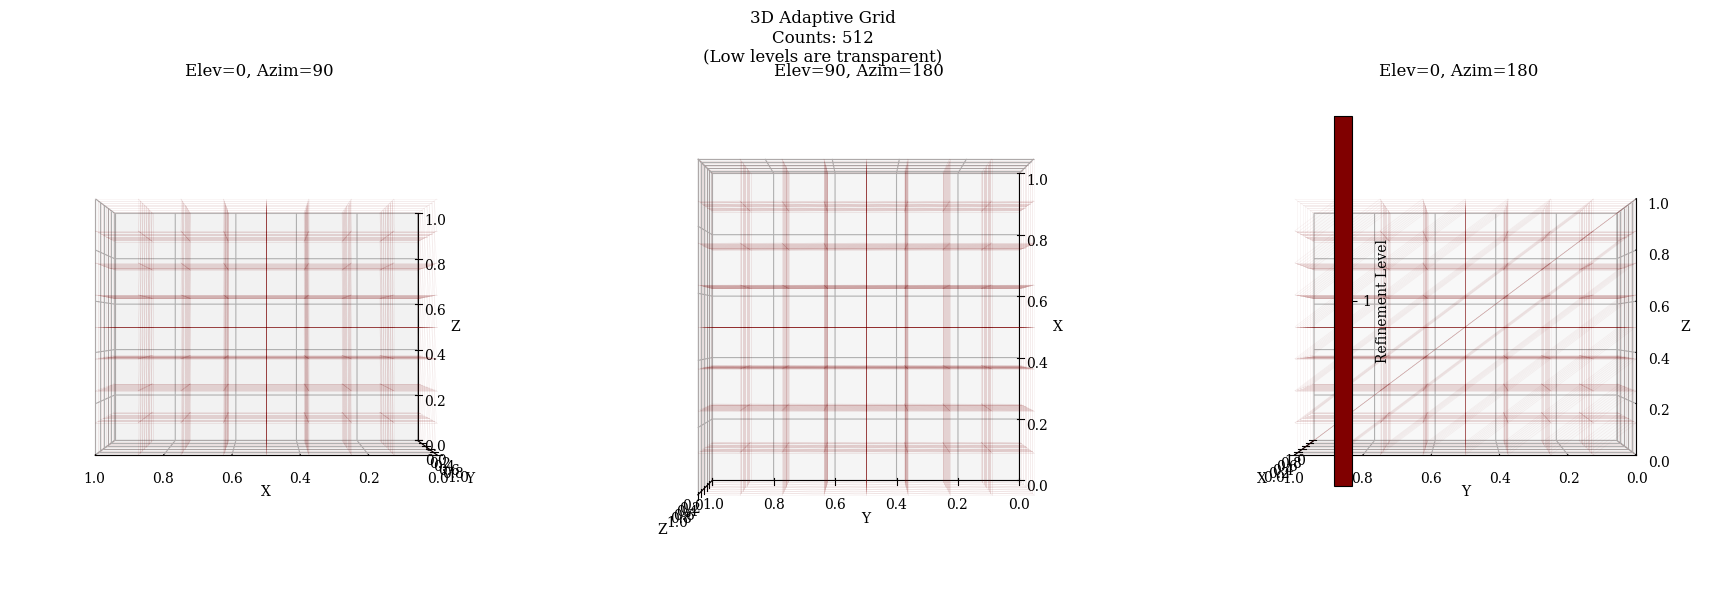

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


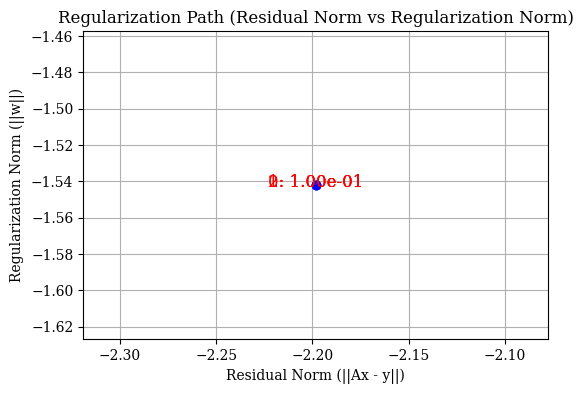

第 1 次迭代的train误差：
S_l_inf= 1.2601140366092711 S_L_2= 0.0017691738006442841 S_l_2= 0.10798513587809419
第 1 次迭代的泛化误差：


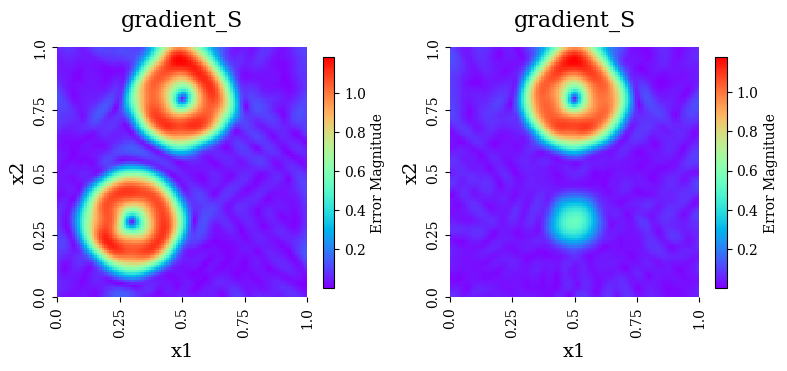

S_l_inf= 2.386276466817233 S_L_2= 0.0017090041986119171 S_l_2= 0.10594704652559474


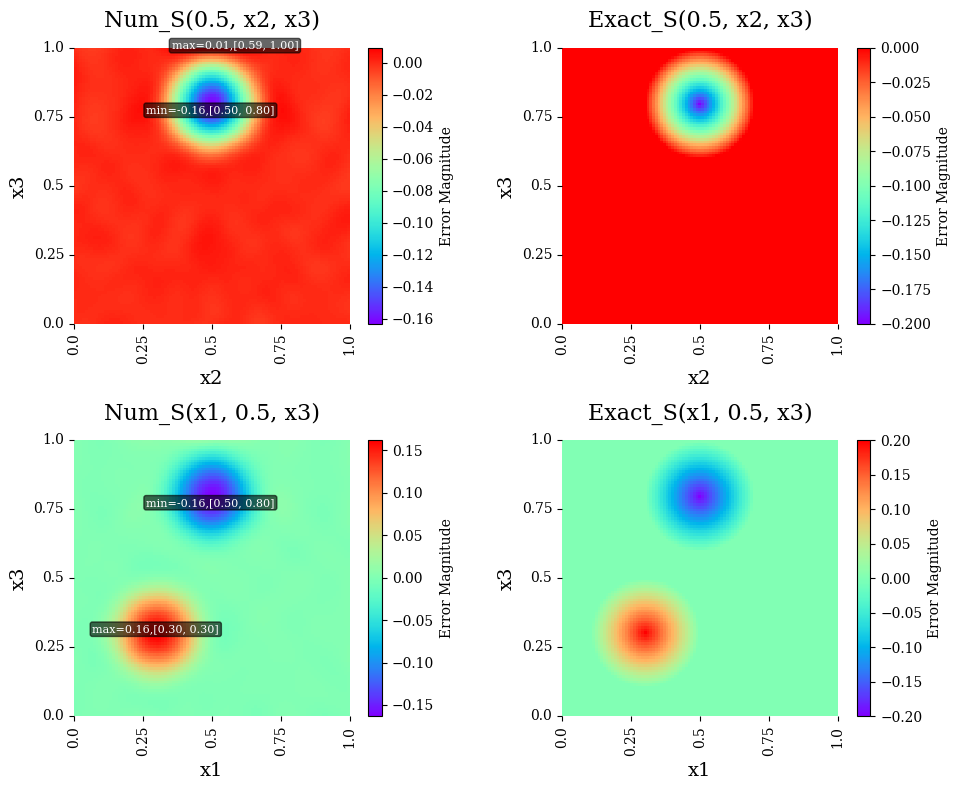

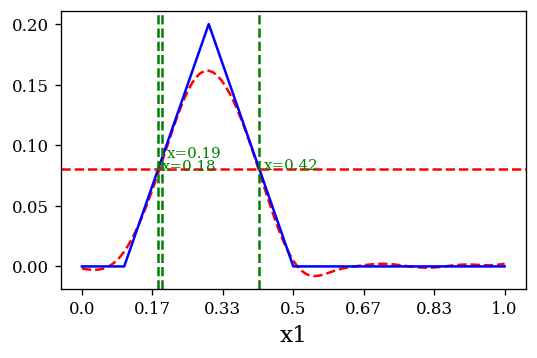

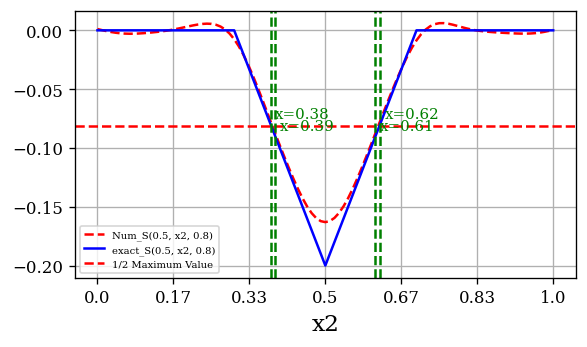

第 1 次自适应网格细分...
S_l_inf= 1.2601140366092711 S_L_2= 0.0017691738006442841 S_l_2= 0.10798513587809419
S_l_inf= 1.7869778035876545 S_L_2= 0.0017269941714629384 S_l_2= 0.1054485625995136
当前总网格数目: 1002
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 1002 cells. Levels: 1 to 2


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.7/./main_code/main_fix1.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


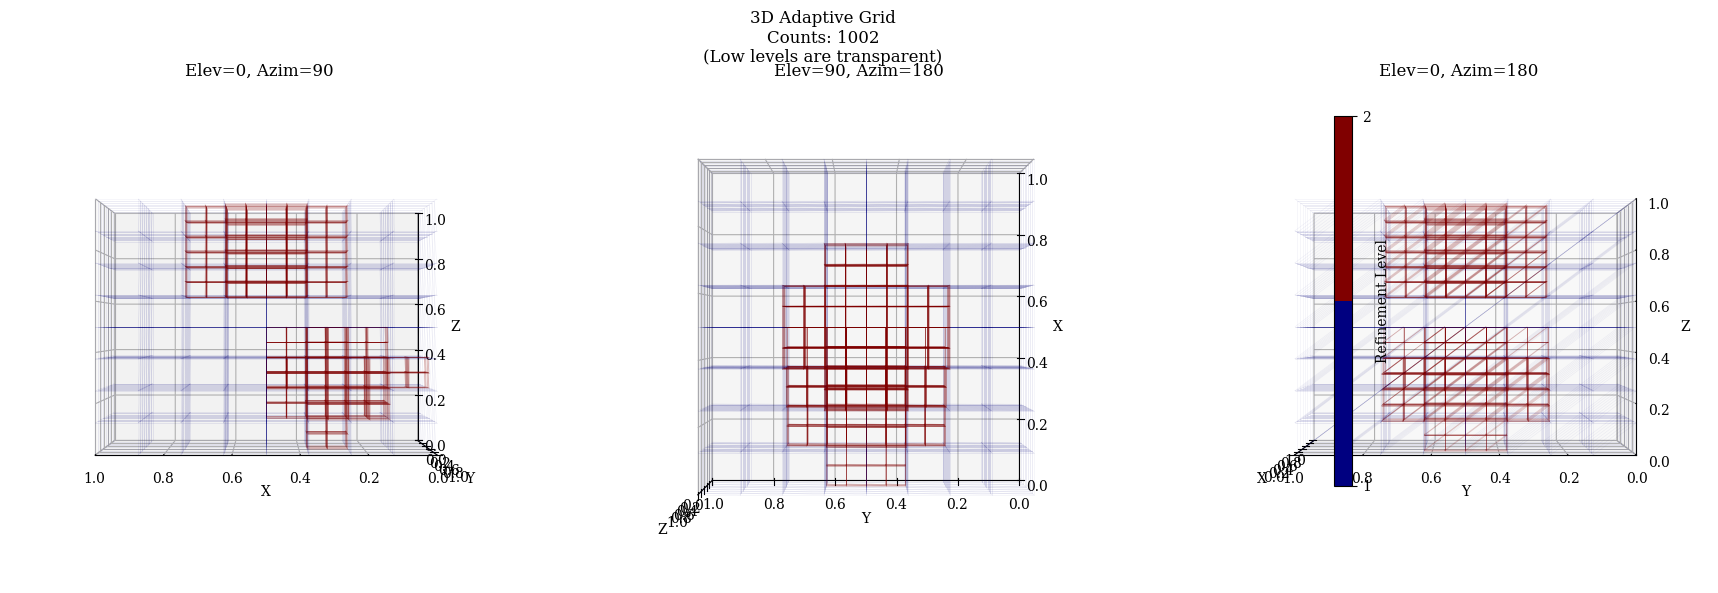

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


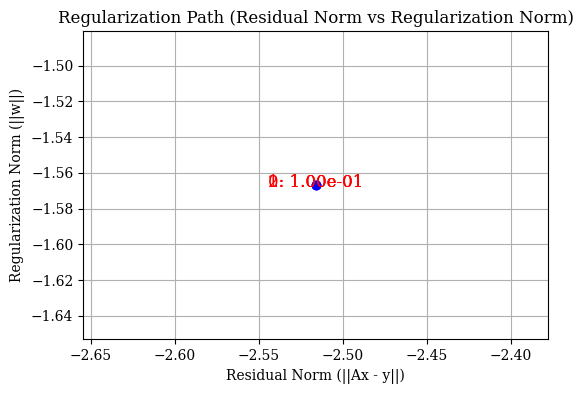

第 2 次迭代的train误差：
S_l_inf= 0.6654166795480679 S_L_2= 0.0022198631316318355 S_l_2= 0.06706026746252078
第 2 次迭代的泛化误差：


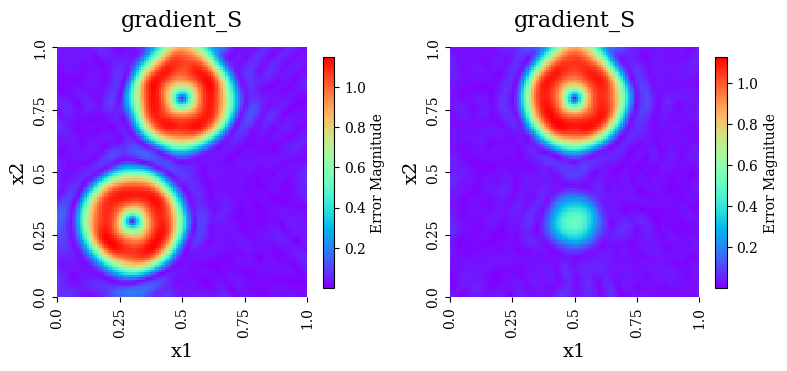

S_l_inf= 1.9618285761400367 S_L_2= 0.0012302648692961203 S_l_2= 0.0762683494001873


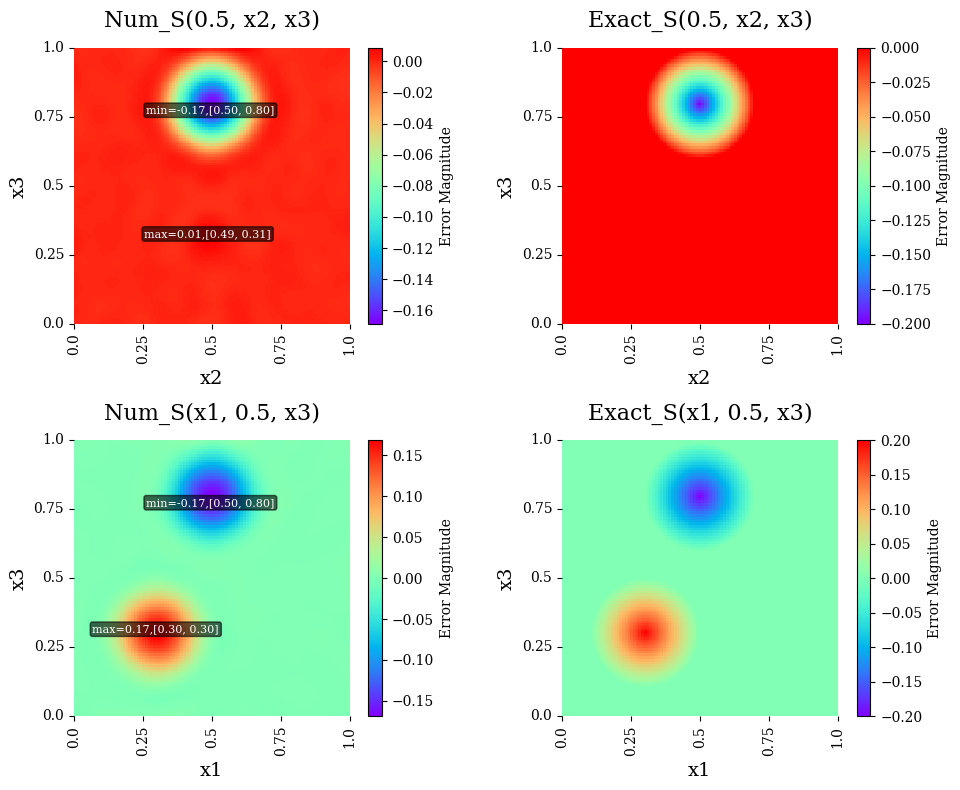

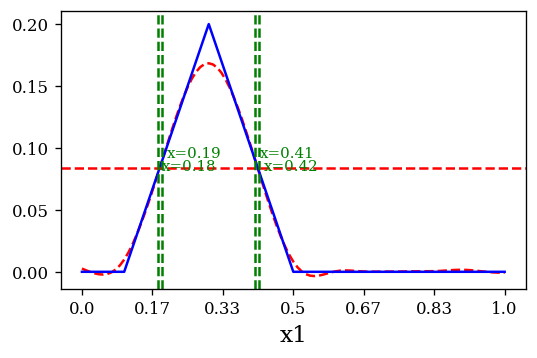

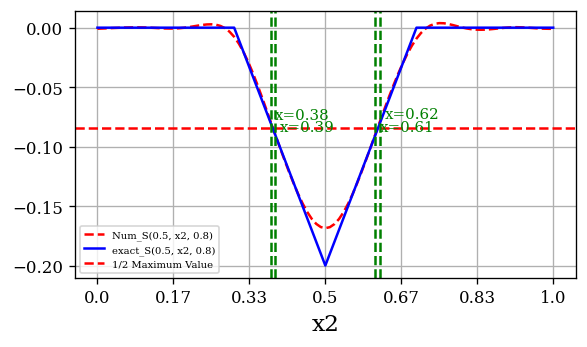

第 2 次自适应网格细分...
S_l_inf= 0.6654166795480679 S_L_2= 0.0022198631316318355 S_l_2= 0.06706026746252078
S_l_inf= 0.7952400522115403 S_L_2= 0.0021720294083645546 S_l_2= 0.06562935880151174
当前总网格数目: 1009
Visualization failed: name 'MeshVisualizer' is not defined


In [7]:
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
delta=10**(-3)
lamb_regu=np.logspace(-1,-1,3)

Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
# refine_threshold_S= [1e-3] * 5
# refine_threshold_grad=[1e-7] * 5
# refine_threshold_noise=[1e-4] * 5
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/100000] * 5
refine_threshold_noise=[1/300] * 5
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_basis=main_fix1.ada_int(iter_int,delta,cells,nx,models0,M,"Tanh",kk,F_81_5_15,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,ratio2,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)